In [198]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv('advertising.csv')
# Explorons rapidement les données avec
df.head()

,tv,radio,journaux,ventes
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [199]:
df.describe()

,tv,radio,journaux,ventes
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


<Axes: xlabel='tv', ylabel='ventes'>

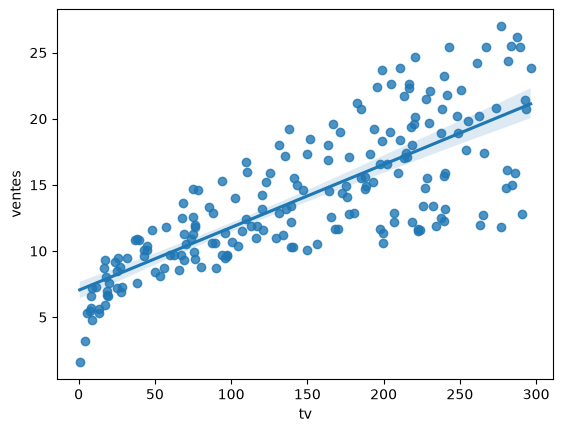

In [200]:
sns.regplot(data=df, x='tv', y ='ventes')

<Axes: xlabel='journaux', ylabel='ventes'>

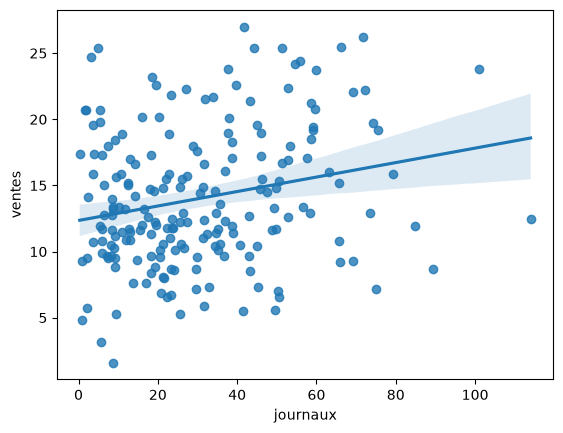

In [201]:
sns.regplot(data=df, x='journaux', y ='ventes')

<Axes: xlabel='radio', ylabel='ventes'>

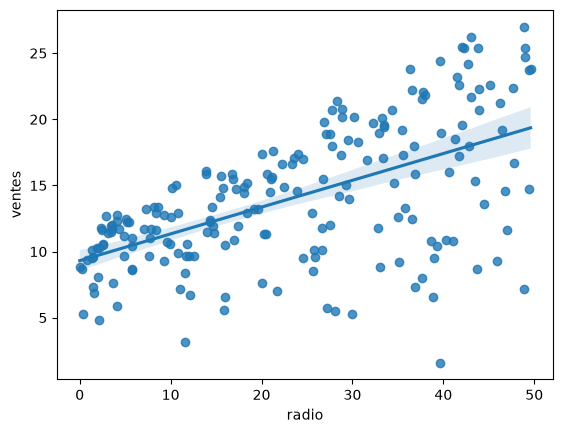

In [202]:
sns.regplot(data=df, x='radio', y ='ventes')

In [203]:
df.corr(method='pearson').loc[['ventes']]

,tv,radio,journaux,ventes
ventes,0.782224,0.576223,0.228299,1.0


In [204]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()

In [205]:
from sklearn.model_selection import train_test_split
X = df[['tv','radio','journaux']]
y = df.ventes

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [206]:
reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[0.04,0.19,0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['tv','radio','journaux']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.979
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [207]:
y_pred_test = reg.predict(X_test)

In [208]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
print(f"RMSE: {mean_squared_error(y_test, y_pred_test)}")
print(f"MAPE: {mean_absolute_percentage_error(y_test, y_pred_test)}")

RMSE: 3.1740973539761033
MAPE: 0.15198846602831226


In [209]:
df['tv2'] = df.tv**2

In [210]:
features = list(df.columns)
features.remove('ventes')

In [211]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
data_array = scaler.fit_transform(df[features])

peut être raccourci en data_array = scaler.fit_transform(df)

In [212]:
df_scaled = pd.DataFrame(data_array, columns = features)

In [213]:
df_scaled.describe().loc[['min','max']]

,tv,radio,journaux,tv2
min,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0


In [214]:
X = df_scaled
y = df.ventes

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

reg.fit(X_train, y_train)
y_hat_test = reg.predict(X_test)

print(f"Coefficients: {reg.coef_}")
print(f"RMSE: {mean_squared_error(y_test, y_hat_test)}")
print(f"MAPE: {mean_absolute_percentage_error(y_test, y_hat_test)}")

Coefficients: [22.35381258  9.51593019  0.55820668 -9.2908828 ]
RMSE: 2.378317089554024
MAPE: 0.13079146046727738


In [215]:
df['tv2'] = df.tv*df.radio

In [216]:
df = df.rename(columns={'tv2' : 'tvradio'})

In [217]:
X = df[['tv','radio','journaux', 'tvradio']]
y = df.ventes

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

reg.fit(X_train, y_train)
y_hat_test = reg.predict(X_test)

print(f"Coefficients: {reg.coef_}")
print(f"RMSE: {mean_squared_error(y_test, y_hat_test)}")
print(f"MAPE: {mean_absolute_percentage_error(y_test, y_hat_test)}")

Coefficients: [0.01961507 0.03397467 0.00190677 0.00104987]
RMSE: 0.8144305830812308
MAPE: 0.07328855467044486
